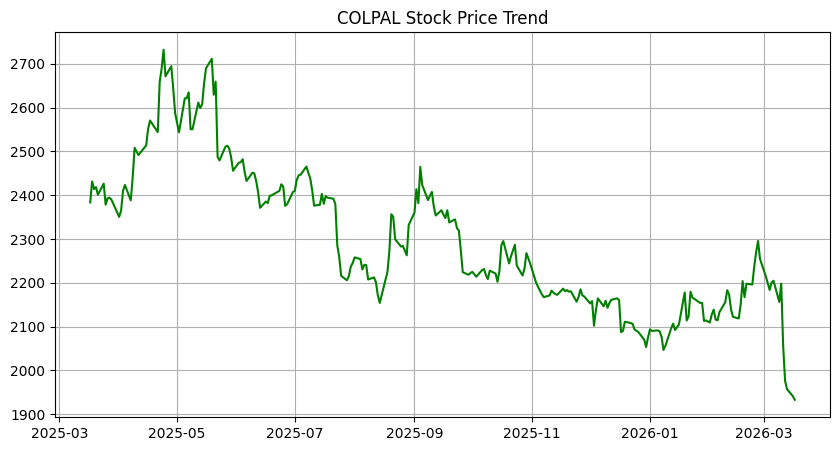

--- ADF Test Result ---
ADF Statistic: -2.326573924541165
p-value: 0.1635405169775947
Result: Data is NOT Stationary (Needs Differencing)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. File load karein (Ab naam 'data.csv' hai)
df = pd.read_csv('data.csv')

# Column names saaf karein
df.columns = df.columns.str.strip()

# (a) Date conversion
df['DATE'] = pd.to_datetime(df['DATE'])

# Convert 'CLOSE' column to numeric, handling commas
df['CLOSE'] = df['CLOSE'].str.replace(',', '').astype(float)

# (b) Missing values handle karein
df = df.dropna()

# (c) Visualize price trend
plt.figure(figsize=(10, 5))
plt.plot(df['DATE'], df['CLOSE'], color='green')
plt.title('COLPAL Stock Price Trend')
plt.grid(True)
plt.show()

# Part (ii-a): ADF Test for Stationarity
print("--- ADF Test Result ---")
result = adfuller(df['CLOSE'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Result: Data is Stationary")
else:
    print("Result: Data is NOT Stationary (Needs Differencing)")

--- ADF Test Results ---
ADF Statistic: -2.326573924541165
p-value: 0.1635405169775947
Result: Data is NOT Stationary (Humne 'd' parameter 1 lena hoga)


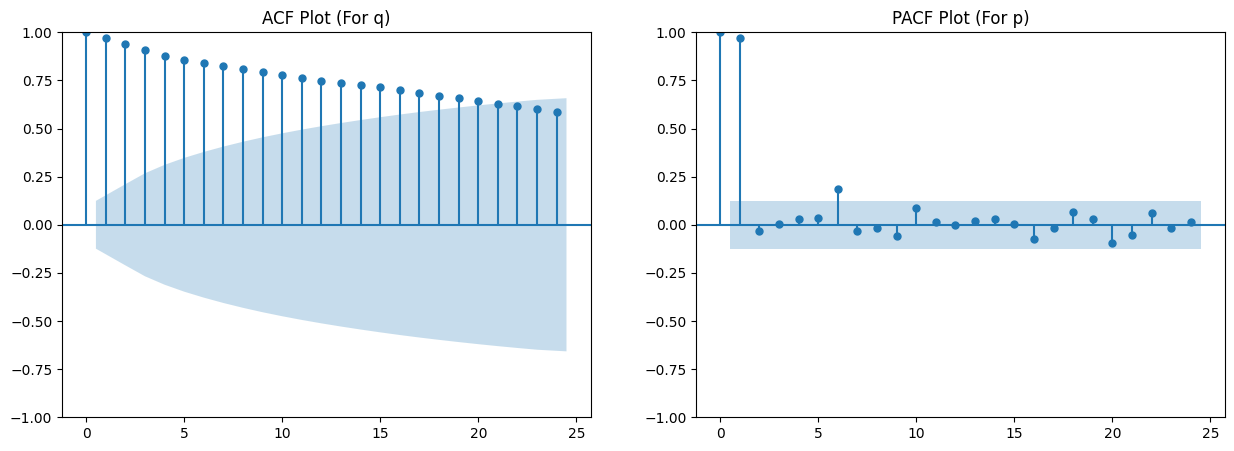

In [8]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. ADF Test (Stationarity check karne ke liye)
print("--- ADF Test Results ---")
result = adfuller(df['CLOSE'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Interpretation
if result[1] <= 0.05:
    print("Result: Data is Stationary (d=0)")
else:
    print("Result: Data is NOT Stationary (Humne 'd' parameter 1 lena hoga)")

# 2. ACF aur PACF Plots (p aur q dhoondne ke liye)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df['CLOSE'], ax=axes[0])
axes[0].set_title('ACF Plot (For q)')
plot_pacf(df['CLOSE'], ax=axes[1])
axes[1].set_title('PACF Plot (For p)')
plt.show()

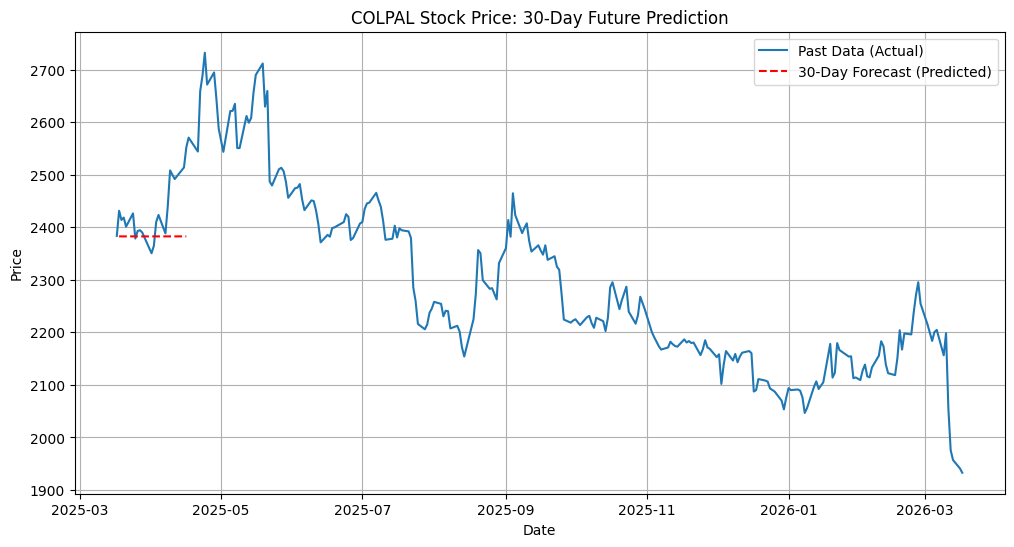

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# 1. Model define karna (p=1, d=1, q=1 basic starting point hai)
# Humne d=1 rakha hai kyunki p-value 0.05 se zyada thi
model = ARIMA(df['CLOSE'], order=(1, 1, 1))
model_fit = model.fit()

# 2. Agle 30 din ki prediction (Forecasting)
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_idx = pd.date_range(start=df['DATE'].iloc[-1], periods=forecast_steps + 1, freq='D')[1:]
forecast_values = forecast.predicted_mean

# 3. Graph mein dikhana (Visualization)
plt.figure(figsize=(12, 6))
plt.plot(df['DATE'], df['CLOSE'], label='Past Data (Actual)')
plt.plot(forecast_idx, forecast_values, label='30-Day Forecast (Predicted)', color='red', linestyle='--')
plt.title('COLPAL Stock Price: 30-Day Future Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

